In [1]:
import xarray as xr

In [2]:
import os
os.chdir("C:\\Users\\zharif\\Documents\\Dataset TA")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: C:\Users\zharif\Documents\Dataset TA


In [3]:
ds_truth = xr.open_zarr("data/era5_indonesia_2018-2022.zarr")
ds_forecast = xr.open_zarr("data/ifs_lowres_indonesia_2018-2022.zarr")

C:\Users\zharif\AppData\Local\Temp\ipykernel_15444\3191457552.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_forecast = xr.open_zarr("data/ifs_lowres_indonesia_2018-2022.zarr")


In [4]:
ds_truth

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    2m_temperature            (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>

In [6]:
ds_truth.to_dataframe()

10m_u_component_of_wind  \
time                latitude longitude                            
2018-01-01 00:00:00  30.0    90.00                     0.737060   
                             90.25                     0.848293   
                             90.50                     0.751659   
                             90.75                     1.359269   
                             91.00                     1.275149   
...                                                         ...   
2022-12-31 18:00:00 -15.0    139.00                    9.118832   
                             139.25                    9.269753   
                             139.50                    9.616480   
                             139.75                    9.967110   
                             140.00                    9.986626   

                                        10m_v_component_of_wind  \
time                latitude longitude                            
2018-01-01 00:00:00  30.0    90.00                     2.006315   
                             90.25                     1.735711   
                             90.50                     1.611551   
                             90.75                     1.079256   
                             91.00                    -0.203726   
...                                                         ...   
2022-12-31 18:00:00 -15.0    139.00                   -4.179657   
                             139.25                   -4.423280   
                             139.50                   -4.873521   
                             139.75                   -5.411652   
                             140.00                   -6.373039   

                                        2m_temperature  \
time                latitude longitude                   
2018-01-01 00:00:00  30.0    90.00          257.477081   
                             90.25          259.331238   
                             90.50          260.596741   
                             90.75          261.198395   
                             91.00          262.092194   
...                                                ...   
2022-12-31 18:00:00 -15.0    139.00         301.053131   
                             139.25         301.656464   
                             139.50         302.035309   
                             139.75         302.041534   
                             140.00         302.055573   

                                        total_precipitation_24hr  
time                latitude longitude                            
2018-01-01 00:00:00  30.0    90.00                      0.000720  
                             90.25                      0.000388  
                             90.50                      0.000194  
                             90.75                      0.000277  
                             91.00                      0.000854  
...                                                          ...  
2022-12-31 18:00:00 -15.0    139.00                     0.069636  
                             139.25                     0.070952  
                             139.50                     0.066852  
                             139.75                     0.061051  
                             140.00                     0.057606  

[265726824 rows x 4 columns]

In [5]:
ds_forecast

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 41, latitude: 30)
Coordinates:
  * latitude                  (latitude) float64 240B -13.5 -12.0 ... 28.5 30.0
  * longitude                 (longitude) float64 328B 90.0 91.5 ... 148.5 150.0
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>

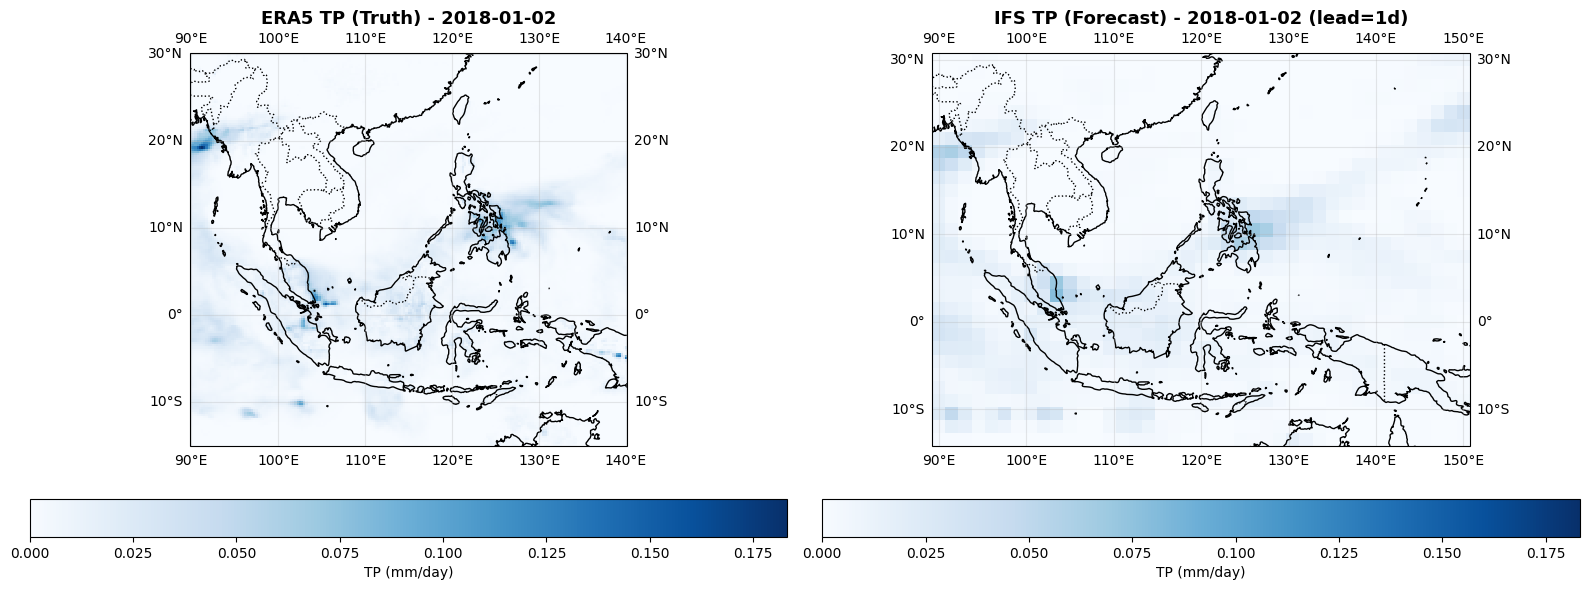

Truth range: 0.00 - 0.18 mm/day
Forecast range: 0.00 - 0.08 mm/day
Common color scale: 0.00 - 0.18 mm/day


In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

data1 = ds_truth['total_precipitation_24hr'].sel(time='2018-01-02').copy()
data2 = ds_forecast['total_precipitation_24hr'].sel(time='2018-01-01', prediction_timedelta='1 days').copy()

# Extract data for 2018-01-01
truth_2018 = data1.isel(time=0)  # Select first timestep
forecast_2018 = data2.isel(time=0)  # Select first timestep

# Determine common color scale range
vmin = min(truth_2018.values.min(), forecast_2018.values.min())
vmax = max(truth_2018.values.max(), forecast_2018.values.max())

# Create map projection
proj = ccrs.PlateCarree()

# Create side-by-side map plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': proj})

# Plot truth
im1 = axes[0].pcolormesh(truth_2018.longitude, truth_2018.latitude, truth_2018.values, 
                          transform=ccrs.PlateCarree(), cmap='Blues', shading='nearest',
                          vmin=vmin, vmax=vmax)
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linestyle=':')
axes[0].gridlines(draw_labels=True, alpha=0.3)
axes[0].set_title('ERA5 TP (Truth) - 2018-01-02', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='TP (mm/day)', orientation='horizontal', pad=0.1)

# Plot forecast
im2 = axes[1].pcolormesh(forecast_2018.longitude.values, forecast_2018.latitude.values, forecast_2018.values.T,
                          transform=ccrs.PlateCarree(), cmap='Blues', shading='auto',
                          vmin=vmin, vmax=vmax)
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linestyle=':')
axes[1].gridlines(draw_labels=True, alpha=0.3)
axes[1].set_title('IFS TP (Forecast) - 2018-01-02 (lead=1d)', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='TP (mm/day)', orientation='horizontal', pad=0.1)

plt.tight_layout()
plt.show()

print(f"Truth range: {truth_2018.values.min():.2f} - {truth_2018.values.max():.2f} mm/day")
print(f"Forecast range: {forecast_2018.values.min():.2f} - {forecast_2018.values.max():.2f} mm/day")
print(f"Common color scale: {vmin:.2f} - {vmax:.2f} mm/day")

In [9]:
ds_forecast['2m_temperature']

<xarray.DataArray '2m_temperature' (time: 3652, prediction_timedelta: 61,
                                    longitude: 41, latitude: 30)> Size: 1GB
dask.array<open_dataset-2m_temperature, shape=(3652, 61, 41, 30), dtype=float32, chunksize=(1, 8, 41, 30), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 240B -13.5 -12.0 ... 28.5 30.0
  * longitude             (longitude) float64 328B 90.0 91.5 ... 148.5 150.0
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 488B 00:00:0...
  * time                  (time) datetime64[ns] 29kB 2018-01-01 ... 2022-12-3...
Attributes:
    long_name:      2 metre temperature
    short_name:     t2m
    standard_name:  unknown
    units:          K

In [10]:
ds_forecast['total_precipitation_24hr'].sel(time='2018-01-01', prediction_timedelta='0 days')

<xarray.DataArray 'total_precipitation_24hr' (time: 2, longitude: 41,
                                              latitude: 30)> Size: 10kB
dask.array<getitem, shape=(2, 41, 30), dtype=float32, chunksize=(1, 41, 30), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 240B -13.5 -12.0 ... 28.5 30.0
  * longitude             (longitude) float64 328B 90.0 91.5 ... 148.5 150.0
    prediction_timedelta  timedelta64[ns] 8B 00:00:00
  * time                  (time) datetime64[ns] 16B 2018-01-01 2018-01-01T12:...

In [20]:
import numpy as np

# Get the selected data
data = ds_forecast['total_precipitation_24hr'].sel(time='2018-01-01', prediction_timedelta='1 days')

print("Data shape:", data.shape)
print("\nData type:", data.dtype)
print("\nCoordinates:")
print(f"  Latitude: {data.latitude.values}")
print(f"  Longitude: {data.longitude.values}")

print("\n=== Numeric Values ===")
print(f"Min: {data.values.min():.4f}")
print(f"Max: {data.values.max():.4f}")
print(f"Mean: {data.values.mean():.4f}")
print(f"Std: {data.values.std():.4f}")

print("\n=== Full Array ===")
data.to_dataframe()

Data shape: (2, 41, 30)

Data type: float32

Coordinates:
  Latitude: [-13.5 -12.  -10.5  -9.   -7.5  -6.   -4.5  -3.   -1.5   0.    1.5   3.
   4.5   6.    7.5   9.   10.5  12.   13.5  15.   16.5  18.   19.5  21.
  22.5  24.   25.5  27.   28.5  30. ]
  Longitude: [ 90.   91.5  93.   94.5  96.   97.5  99.  100.5 102.  103.5 105.  106.5
 108.  109.5 111.  112.5 114.  115.5 117.  118.5 120.  121.5 123.  124.5
 126.  127.5 129.  130.5 132.  133.5 135.  136.5 138.  139.5 141.  142.5
 144.  145.5 147.  148.5 150. ]

=== Numeric Values ===
Min: 0.0000
Max: 0.0872
Mean: 0.0068
Std: 0.0097

=== Full Array ===


prediction_timedelta  \
time                longitude latitude                        
2018-01-01 00:00:00 90.0      -13.5                  1 days   
                              -12.0                  1 days   
                              -10.5                  1 days   
                              -9.0                   1 days   
                              -7.5                   1 days   
...                                                     ...   
2018-01-01 12:00:00 150.0      24.0                  1 days   
                               25.5                  1 days   
                               27.0                  1 days   
                               28.5                  1 days   
                               30.0                  1 days   

                                        total_precipitation_24hr  
time                longitude latitude                            
2018-01-01 00:00:00 90.0      -13.5                     0.001296  
                              -12.0                     0.005668  
                              -10.5                     0.023207  
                              -9.0                      0.015951  
                              -7.5                      0.012808  
...                                                          ...  
2018-01-01 12:00:00 150.0      24.0                     0.020873  
                               25.5                     0.004824  
                               27.0                     0.001533  
                               28.5                     0.001047  
                               30.0                     0.001250  

[2460 rows x 2 columns]

## Downscaling IFS Forecast to ERA5 Resolution using xESMF

We'll regrid the lower-resolution IFS forecast onto the higher-resolution ERA5 grid.

In [1]:
import xesmf as xe

# Select a specific time and lead time from forecast
forecast_sample = ds_forecast['total_precipitation_24hr'].sel(
    time='2018-01-01', 
    prediction_timedelta='1 days'
).isel(time=0)

# Select corresponding truth data
truth_sample = ds_truth['total_precipitation_24hr'].sel(time='2018-01-02').isel(time=0)
print(f"Forecast shape: {forecast_sample.shape}")
print(f"Truth shape: {truth_sample.shape}")
print(f"Forecast resolution: lat={len(forecast_sample.latitude)}, lon={len(forecast_sample.longitude)}")
print(f"Truth resolution: lat={len(truth_sample.latitude)}, lon={len(truth_sample.longitude)}")

# Create regridder for downscaling (bilinear is common for precipitation spatial interpolation)
regridder = xe.Regridder(
    forecast_sample,
    truth_sample,
    method='bilinear',  # Use 'conservative' for mass-conserving downscaling
    periodic=False
)

# Apply regridding to downscale forecast to truth resolution
forecast_downscaled = regridder(forecast_sample)

print(f"\nDownscaled forecast shape: {forecast_downscaled.shape}")
print(f"Downscaled matches truth grid: {forecast_downscaled.shape == truth_sample.shape}")

NameError: name 'ds_forecast' is not defined

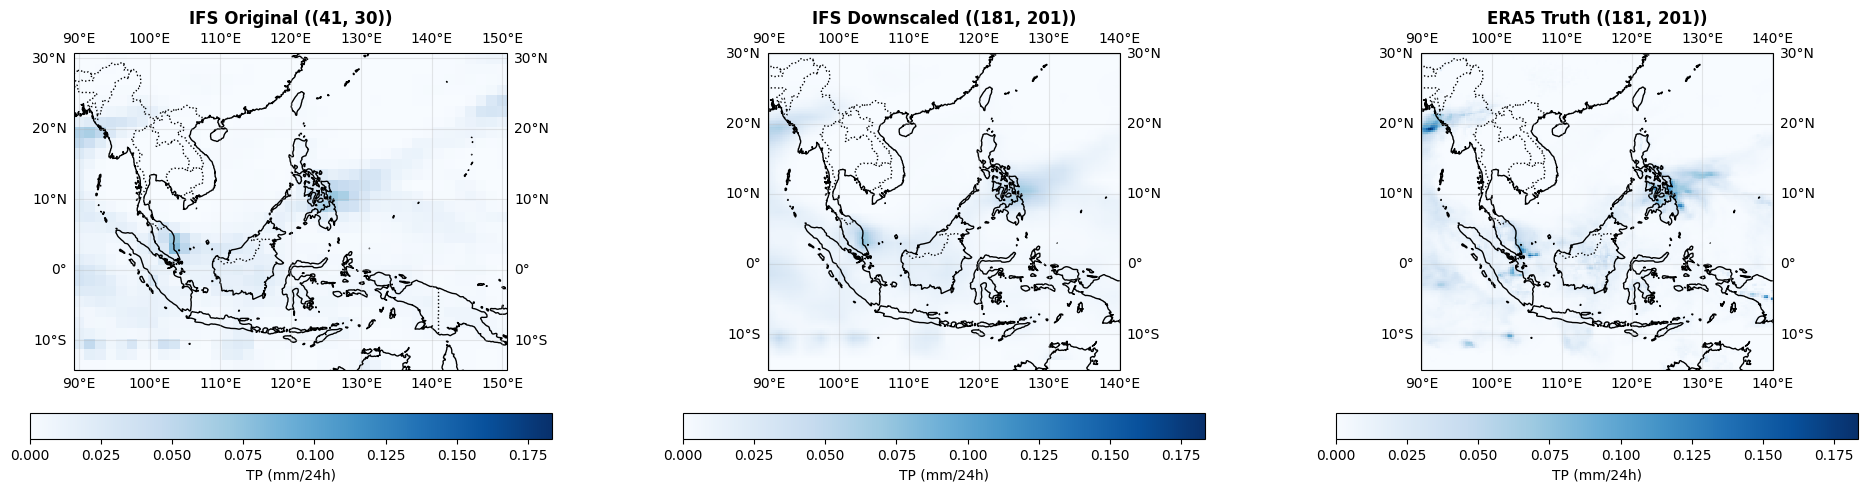

Original forecast: 0.00 - 0.08 mm/24h
Downscaled forecast: 0.00 - 0.08 mm/24h
Truth: 0.00 - 0.18 mm/24h


In [24]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Determine common color scale
vmin = min(truth_sample.values.min(), forecast_downscaled.values.min())
vmax = max(truth_sample.values.max(), forecast_downscaled.values.max())

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(20, 5), subplot_kw={'projection': proj})

# Original forecast (low res)
im0 = axes[0].pcolormesh(forecast_sample.longitude, forecast_sample.latitude, 
                          forecast_sample.values.T,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linestyle=':')
axes[0].gridlines(draw_labels=True, alpha=0.3)
axes[0].set_title(f'IFS Original ({forecast_sample.shape})', fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[0], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# Downscaled forecast (high res)
im1 = axes[1].pcolormesh(forecast_downscaled.longitude, forecast_downscaled.latitude, 
                          forecast_downscaled.values,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linestyle=':')
axes[1].gridlines(draw_labels=True, alpha=0.3)
axes[1].set_title(f'IFS Downscaled ({forecast_downscaled.shape})', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[1], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# Truth (high res)
im2 = axes[2].pcolormesh(truth_sample.longitude, truth_sample.latitude, 
                          truth_sample.values,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[2].coastlines()
axes[2].add_feature(cfeature.BORDERS, linestyle=':')
axes[2].gridlines(draw_labels=True, alpha=0.3)
axes[2].set_title(f'ERA5 Truth ({truth_sample.shape})', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[2], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

plt.tight_layout()
plt.show()

print(f"Original forecast: {forecast_sample.values.min():.2f} - {forecast_sample.values.max():.2f} mm/24h")
print(f"Downscaled forecast: {forecast_downscaled.values.min():.2f} - {forecast_downscaled.values.max():.2f} mm/24h")
print(f"Truth: {truth_sample.values.min():.2f} - {truth_sample.values.max():.2f} mm/24h")

c:\Users\zharif\miniconda3\Lib\site-packages\xarray\groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\zharif\miniconda3\Lib\site-packages\xarray\groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


Forecast weekly shape: (60,)
Truth weekly shape (shifted by 15 days): (60,)
Time range: 2018-01-31T00:00:00.000000000 to 2022-12-31T00:00:00.000000000


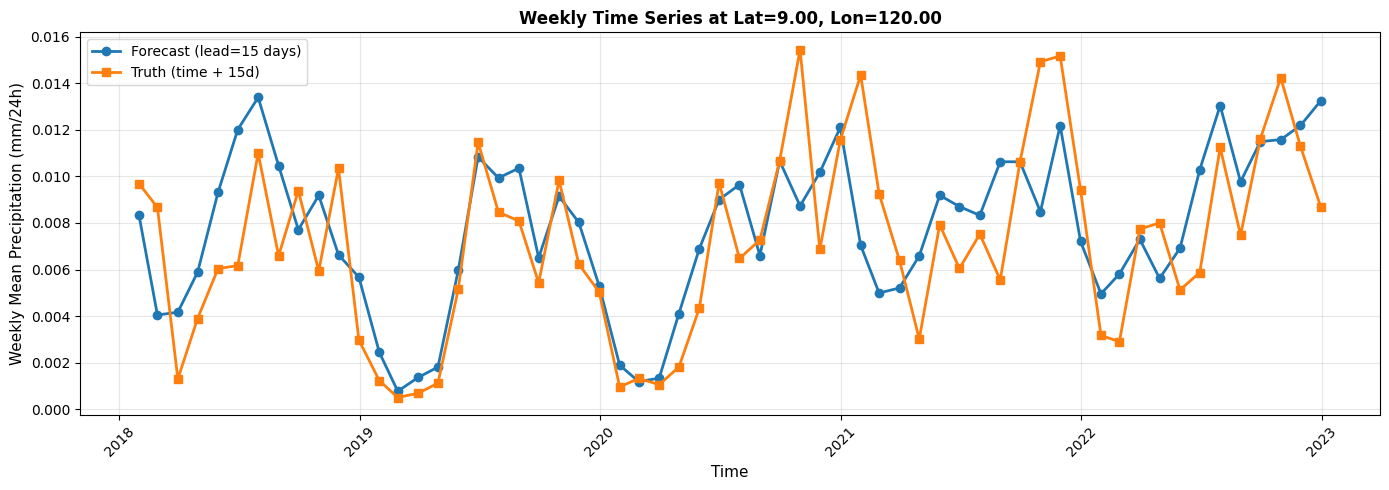


Forecast weekly - mean: 0.01, std: 0.00
Truth weekly - mean: 0.01, std: 0.00
Correlation: 0.7140


In [28]:
# Pick a coordinate and plot WEEKLY time series
lat_idx, lon_idx = 15, 20  # Example indices
lat_val = forecast_sample.latitude.values[lat_idx]
lon_val = forecast_sample.longitude.values[lon_idx]

# Define lead time
lead_time_str = '15 days'
lead_time_days = 15

# Extract time series for this location from full datasets
forecast_ts = ds_forecast['total_precipitation_24hr'].sel(
    latitude=lat_val, 
    longitude=lon_val, 
    prediction_timedelta=lead_time_str,
    method='nearest'
)
truth_ts = ds_truth['total_precipitation_24hr'].sel(
    latitude=lat_val, 
    longitude=lon_val,
    method='nearest'
)

# Calculate weekly means
# For forecast: resample to weekly
forecast_weekly = forecast_ts.resample(time='M').mean()

# For truth: shift by lead_time_days and resample to weekly
# When forecast is at time T with lead_time days, truth should be at T + lead_time_days
truth_ts_shifted = truth_ts.shift(time=-lead_time_days)
truth_weekly = truth_ts_shifted.resample(time='M').mean()

# Align the two time series
forecast_weekly_aligned, truth_weekly_aligned = xr.align(
    forecast_weekly, truth_weekly, join='inner'
)

print(f"Forecast weekly shape: {forecast_weekly_aligned.shape}")
print(f"Truth weekly shape (shifted by {lead_time_days} days): {truth_weekly_aligned.shape}")
print(f"Time range: {forecast_weekly_aligned.time.values[0]} to {forecast_weekly_aligned.time.values[-1]}")

# Plot weekly time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(forecast_weekly_aligned.time.values, forecast_weekly_aligned.values, 
        label=f'Forecast (lead={lead_time_str})', marker='o', linewidth=2, markersize=6)
ax.plot(truth_weekly_aligned.time.values, truth_weekly_aligned.values, 
        label=f'Truth (time + {lead_time_days}d)', marker='s', linewidth=2, markersize=6)
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Weekly Mean Precipitation (mm/24h)', fontsize=11)
ax.set_title(f'Weekly Time Series at Lat={lat_val:.2f}, Lon={lon_val:.2f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nForecast weekly - mean: {forecast_weekly_aligned.values.mean():.2f}, std: {forecast_weekly_aligned.values.std():.2f}")
print(f"Truth weekly - mean: {truth_weekly_aligned.values.mean():.2f}, std: {truth_weekly_aligned.values.std():.2f}")
print(f"Correlation: {np.corrcoef(forecast_weekly_aligned.values, truth_weekly_aligned.values)[0, 1]:.4f}")